# Variance ellipse function Testing  

**Purpose**: Code for testing the variance ellipse functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [6]:
%matplotlib inline


Import python libraries


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import cmocean.cm as cmo

# Set path to access python functions
sys.path.append('/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling/tools/')

#--- Luke's Python Functions ---# 
from autocorr import compute_decor_scale, compute_autocorr

In [9]:
#--- Compute Variance Ellipse ---# 
def compute_variance_ellipse(u, v, lat=None, use_weights=True):
    """
    Compute the spatial variance ellipse and rotated velocity components
    from 2D u,v velocity fields in a subregion.

    Parameters
    ----------
    u, v : 2D arrays
        Velocity components within the spatial subregion (same shape).
        Units: m/s (or consistent velocity units).
    lat : 2D array, optional
        Latitude field (degrees) for area weighting via cos(latitude).
        Only used if `use_weights=True`.
    use_weights : bool, default=True
        If True, apply area weighting proportional to cos(latitude).

    Returns
    -------
    theta : float
        Orientation of the major axis **in degrees clockwise from North**.
        (0° = North, 90° = East, 180° = South, 270° = West)
    a : float
        Standard deviation (sqrt of variance) along the semi-major axis.
    b : float
        Standard deviation (sqrt of variance) along the semi-minor axis.
    u_rot, v_rot : 2D arrays
        Velocity anomalies rotated into the major/minor coordinate system:
        - u_rot → along-major-axis component
        - v_rot → along-minor-axis component

    Notes
    -----
    - NaNs are ignored when computing covariance and means.
    - Area weighting ensures each grid cell contributes proportionally
      to its surface area on Earth (∝ cos(latitude)).
    - Orientation follows oceanographic convention (bearing from North,
      increasing clockwise).
    - Rotation follows the classical variance ellipse convention
      (Davis/Rudnick/Gille, SIO 221B Lecture 4):
         θ = ½ * atan2(2<uv>, <u²> − <v²>)
    """

    # Import Library 
    import numpy as np

    # -------------------------------------------------------------
    # 1. Flatten inputs and remove NaNs
    # -------------------------------------------------------------
    # We treat the 2D subregion as a collection of N samples.
    # Flattening simplifies covariance computations as 1D inner products.
    uu = np.ravel(u)
    vv = np.ravel(v)

    # Boolean mask of valid (non-NaN) points
    mask = np.isfinite(uu) & np.isfinite(vv)

    # Extract valid values
    uu = uu[mask]
    vv = vv[mask]

    # -------------------------------------------------------------
    # 2. Define weights (area weighting using cos(latitude))
    # -------------------------------------------------------------
    if lat is not None and use_weights:
        # Use latitude at each grid cell to compute weight ∝ cos(lat)
        ww = np.ravel(np.cos(np.deg2rad(lat)))[mask]
    else:
        # Default to uniform weighting (equal area assumption)
        ww = np.ones(mask.sum())

    # Normalize total weight
    W = ww.sum()

    # -------------------------------------------------------------
    # 3. Compute weighted means and anomalies
    # -------------------------------------------------------------
    # Weighted mean removes any large-scale offset in u,v fields.
    u_mean = np.sum(ww * uu) / W
    v_mean = np.sum(ww * vv) / W

    # Velocity anomalies relative to spatial mean
    u_prime = uu - u_mean
    v_prime = vv - v_mean

    # -------------------------------------------------------------
    # 4. Compute weighted covariance components
    # -------------------------------------------------------------
    # These are spatial (not temporal) covariances:
    # <u'²>, <v'²>, and <u'v'>
    Cuu = np.sum(ww * u_prime * u_prime) / W
    Cvv = np.sum(ww * v_prime * v_prime) / W
    Cuv = np.sum(ww * u_prime * v_prime) / W

    # Construct covariance matrix
    C = np.array([[Cuu, Cuv],
                  [Cuv, Cvv]])

    # -------------------------------------------------------------
    # 5. Eigen-decomposition → principal axes of the covariance matrix
    # -------------------------------------------------------------
    # Eigenvalues correspond to variances along the ellipse's axes.
    # Eigenvectors give the directions of those axes.
    eigvals, eigvecs = np.linalg.eigh(C)        # sorted ascending by default
    lam1, lam2 = eigvals[1], eigvals[0]         # major, minor variances

    # Semi-major (a) and semi-minor (b) standard deviations
    a = np.sqrt(lam1)
    b = np.sqrt(lam2)

    # Major-axis unit vector (east,north components)
    e_major = eigvecs[:, 1]

    # Orientation angle of major axis (radians, CCW from East, x-axis)
    theta = np.arctan2(e_major[1], e_major[0])

    # -------------------------------------------------------------
    # Note on eigen-decomposition vs. analytic solution
    # -------------------------------------------------------------
    # The eigen-decomposition of the 2×2 covariance matrix C is
    # mathematically equivalent to the analytic variance-ellipse
    # solution derived in Davis, Rudnick & Gille (SIOC 221B Lecture 4):
    #
    #   tan(2θ) = 2Cuv / (Cuu − Cvv)
    #   a²,b² = ½[(Cuu + Cvv) ± √((Cuu − Cvv)² + 4Cuv²)]
    #
    # In both approaches:
    #   • The eigenvectors give the principal-axis directions (θ)
    #   • The eigenvalues give the variances along those axes (a²,b²)
    #
    # Eigen-decomposition is used here because it is numerically
    # stable, automatically provides orthogonal unit vectors, and
    # generalizes to higher-dimensional covariance matrices.

    # -------------------------------------------------------------
    # 6. Convert to oceanographic convention (clockwise from North)
    # -------------------------------------------------------------
    # Convert to clockwise reference north
    theta_north = (np.pi/2 - theta) % (2 * np.pi)  # Units: radians

    # Convert to degrees
    theta_north_deg = np.degrees(theta_north)      

    # -------------------------------------------------------------
    # 6. Rotate velocity anomalies into the major/minor coordinate system
    # -------------------------------------------------------------
    # To express the field in the rotated coordinate frame:
    # Perform a clockwise rotation by θ so that the x'-axis
    # aligns with the major axis of the variance ellipse.
    cos_t, sin_t = np.cos(theta_north), np.sin(theta_north)

    # Recreate 2D anomaly fields (NaNs restored in original shape)
    u_prime_2d = np.full_like(u, np.nan)
    v_prime_2d = np.full_like(v, np.nan)
    u_prime_2d.flat[mask] = u_prime
    v_prime_2d.flat[mask] = v_prime

    # Apply clockwise rotation by θ:
    #   [u_rot]   [ cosθ   sinθ][u']
    #   [v_rot] = [-sinθ   cosθ][v']
    u_rot =  u_prime_2d * cos_t + v_prime_2d * sin_t   # along-major-axis component
    v_rot = -u_prime_2d * sin_t + v_prime_2d * cos_t   # along-minor-axis component

    # -------------------------------------------------------------
    # 7. Return results
    # -------------------------------------------------------------
    return theta_north_deg, a, b, u_rot, v_rot


Run the function on fake data

--- Variance Ellipse Results ---
Orientation (clockwise from North): 44.64°
Semi-major std (a): 1.953
Semi-minor std (b): 0.498


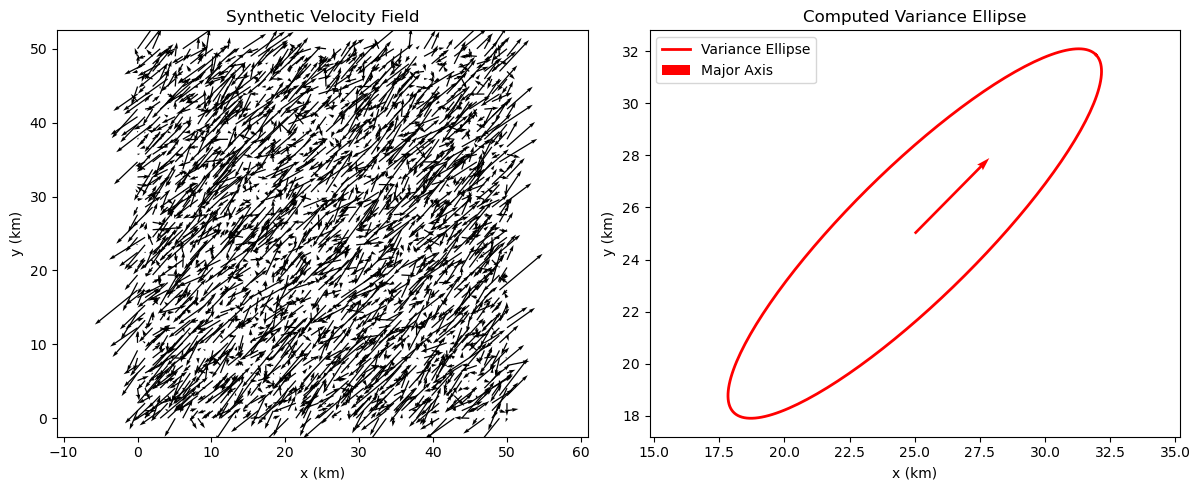

(np.float64(-0.5102040816326531),
 np.float64(50.51020408163265),
 np.float64(-0.5102040816326531),
 np.float64(50.51020408163265))

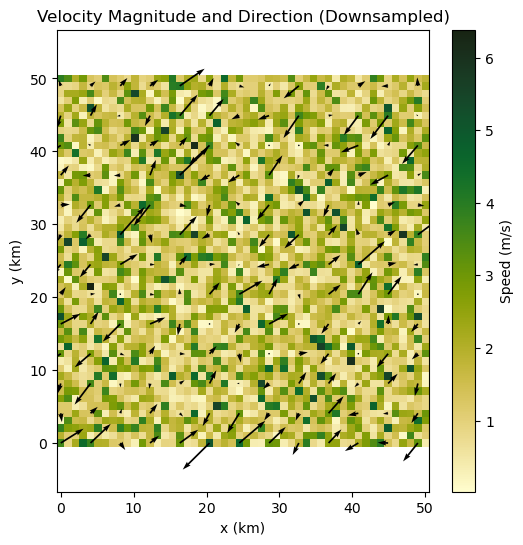

In [17]:
# ===============================================================
# 1. Create a synthetic velocity field on a spatial grid
# ===============================================================

# Define grid (50x50 km region with 2-km resolution)
nx, ny = 50, 50
x = np.linspace(0, 50, nx)  # km
y = np.linspace(0, 50, ny)  # km
X, Y = np.meshgrid(x, y)

# Define "true" flow orientation and variance anisotropy
theta_true_deg = 45.0   # flow oriented NE–SW
theta_true = np.deg2rad(theta_true_deg)
a_true = 2.0             # variance amplitude along major axis
b_true = 0.5             # variance amplitude along minor axis

# Generate synthetic spatially varying velocity anomalies
np.random.seed(0)
u_prime_axis = np.random.normal(scale=a_true, size=(ny, nx))
v_prime_axis = np.random.normal(scale=b_true, size=(ny, nx))

# Rotate the anomalies into east/north components
cos_t, sin_t = np.cos(theta_true), np.sin(theta_true)
u =  u_prime_axis * cos_t - v_prime_axis * sin_t
v =  u_prime_axis * sin_t + v_prime_axis * cos_t

# Add small mean flow and spatial trend
u += 0.1 * (X / X.max())
v += 0.1 * (Y / Y.max())

# ===============================================================
# 2. Compute variance ellipse from the spatial velocity field
# ===============================================================
theta_deg, a, b, u_rot, v_rot = compute_variance_ellipse(u, v)

print(f"--- Variance Ellipse Results ---")
print(f"Orientation (clockwise from North): {theta_deg:.2f}°")
print(f"Semi-major std (a): {a:.3f}")
print(f"Semi-minor std (b): {b:.3f}")

# ===============================================================
# 3. Visualize velocity field and resulting variance ellipse
# ===============================================================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# --- Panel 1: Original velocity field ---
ax[0].quiver(X, Y, u, v, scale=50)
ax[0].set_title("Synthetic Velocity Field")
ax[0].set_xlabel("x (km)")
ax[0].set_ylabel("y (km)")
ax[0].axis('equal')

# --- Panel 2: Variance ellipse ---
def plot_ellipse(ax, x0, y0, a, b, theta_deg, **kwargs):
    """Helper for plotting an ellipse at (x0,y0)."""
    t = np.linspace(0, 2*np.pi, 200)
    x = a * np.cos(t)
    y = b * np.sin(t)
    theta = np.deg2rad(theta_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    xy = R @ np.vstack((x, y))
    ax.plot(x0 + xy[0], y0 + xy[1], **kwargs)

# Plot the variance ellipse at the domain center
x0, y0 = X.mean(), Y.mean()
plot_ellipse(ax[1], x0, y0, a*5, b*5, theta_deg, color='r', lw=2, label='Variance Ellipse')  # scaled up for visibility

# Also plot principal axis directions
ax[1].quiver(x0, y0, np.sin(np.deg2rad(theta_deg)), np.cos(np.deg2rad(theta_deg)),
             scale=5, color='r', width=0.005, label='Major Axis')

ax[1].set_title("Computed Variance Ellipse")
ax[1].set_xlabel("x (km)")
ax[1].set_ylabel("y (km)")
ax[1].legend()
ax[1].axis('equal')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 6))
speed = np.sqrt(u**2 + v**2)

# Colored background for magnitude
cf = ax.pcolormesh(X, Y, speed, cmap=cmo.speed, shading='auto')
plt.colorbar(cf, ax=ax, label='Speed (m/s)')

# Downsampled quiver overlay
step = 4
ax.quiver(X[::step, ::step], Y[::step, ::step],
          u[::step, ::step], v[::step, ::step],
          color='k', scale=50)

ax.set_title("Velocity Magnitude and Direction (Downsampled)")
ax.set_xlabel("x (km)")
ax.set_ylabel("y (km)")
ax.axis('equal')


Covariance matrix:
[[2.37895317 1.79236207]
 [1.79236207 1.75049636]]

Analytic results:
  θ (radians) = 0.6986
  θ (degrees CCW from east) = 40.03
  a = 1.971,  b = 0.495

Eigen-decomposition results:
  θ (radians) = -2.4430
  θ (degrees CCW from east) = -139.97
  a = 1.971,  b = 0.495

Fixed-angle comparison (normalized to [0,180°)):
  Analytic θ = 40.03°
  Eigen θ    = 40.03°
  Δθ = 7.11e-15°
  Δa = 0.0000e+00
  Δb = 1.1102e-16


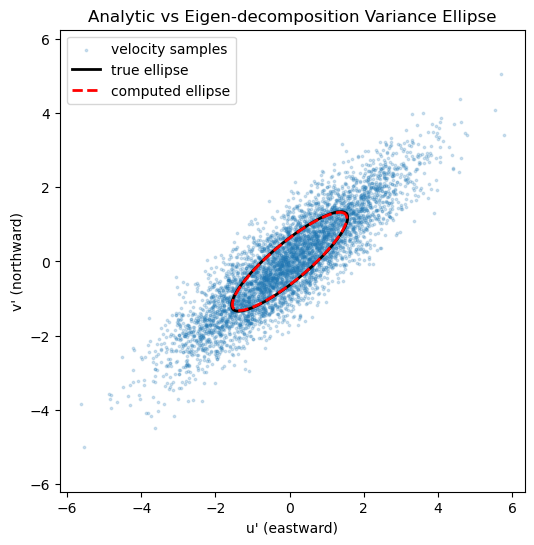

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# 1. Generate synthetic velocity anomaly data
# ===============================================================
# We'll create a "tilted" velocity cloud to visualize the variance ellipse.

np.random.seed(0)

# True parameters for a synthetic velocity field
a_true = 2.0   # true std along major axis
b_true = 0.5   # true std along minor axis
theta_true_deg = 40.0  # true orientation (clockwise from north, for illustration)
theta_true = np.deg2rad(theta_true_deg)

# Generate random samples in the ellipse-aligned coordinate frame
n = 5000
u_prime_axis = np.random.normal(scale=a_true, size=n)
v_prime_axis = np.random.normal(scale=b_true, size=n)

# Rotate them into east/north components (CCW in mathematical sense)
# To mimic physical u,v fields
cos_t, sin_t = np.cos(theta_true), np.sin(theta_true)
u =  u_prime_axis * cos_t - v_prime_axis * sin_t
v =  u_prime_axis * sin_t + v_prime_axis * cos_t

# ===============================================================
# 2. Compute the covariance matrix of (u,v)
# ===============================================================
Cuu = np.mean(u**2)
Cvv = np.mean(v**2)
Cuv = np.mean(u*v)
C = np.array([[Cuu, Cuv],
              [Cuv, Cvv]])

print("Covariance matrix:")
print(C)

# ===============================================================
# 3. Analytic solution (from lecture notes)
# ===============================================================
theta_analytic = 0.5 * np.arctan2(2*Cuv, (Cuu - Cvv))
a2_analytic = 0.5 * ((Cuu + Cvv) + np.sqrt((Cuu - Cvv)**2 + 4*Cuv**2))
b2_analytic = 0.5 * ((Cuu + Cvv) - np.sqrt((Cuu - Cvv)**2 + 4*Cuv**2))
a_analytic, b_analytic = np.sqrt(a2_analytic), np.sqrt(b2_analytic)

print("\nAnalytic results:")
print(f"  θ (radians) = {theta_analytic:.4f}")
print(f"  θ (degrees CCW from east) = {np.degrees(theta_analytic):.2f}")
print(f"  a = {a_analytic:.3f},  b = {b_analytic:.3f}")

# ===============================================================
# 4. Eigen-decomposition solution
# ===============================================================
eigvals, eigvecs = np.linalg.eigh(C)   # sorted ascending
lam1, lam2 = eigvals[1], eigvals[0]    # major, minor
a_eig, b_eig = np.sqrt(lam1), np.sqrt(lam2)

# Major-axis eigenvector (x=east, y=north components)
e_major = eigvecs[:, 1]
theta_eig = np.arctan2(e_major[1], e_major[0])  # CCW from east

print("\nEigen-decomposition results:")
print(f"  θ (radians) = {theta_eig:.4f}")
print(f"  θ (degrees CCW from east) = {np.degrees(theta_eig):.2f}")
print(f"  a = {a_eig:.3f},  b = {b_eig:.3f}")

# ===============================================================
# 5. Comparison and verification (fixed for 180° ambiguity)
# ===============================================================
theta_analytic_deg = np.degrees(theta_analytic)
theta_eig_deg = np.degrees(theta_eig)

# Normalize both to [0, 180) since orientations 180° apart are equivalent
theta_analytic_deg = theta_analytic_deg % 180
theta_eig_deg = theta_eig_deg % 180

delta_theta = np.abs(theta_analytic_deg - theta_eig_deg)

print("\nFixed-angle comparison (normalized to [0,180°)):")
print(f"  Analytic θ = {theta_analytic_deg:.2f}°")
print(f"  Eigen θ    = {theta_eig_deg:.2f}°")
print(f"  Δθ = {delta_theta:.2e}°")
print(f"  Δa = {a_analytic - a_eig:.4e}")
print(f"  Δb = {b_analytic - b_eig:.4e}")

# ===============================================================
# 6. Visualization of the synthetic velocity cloud and ellipse
# ===============================================================
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(u, v, s=3, alpha=0.2, label='velocity samples')

# Function to plot ellipse
def plot_ellipse(ax, a, b, theta, **kwargs):
    t = np.linspace(0, 2*np.pi, 200)
    x = a * np.cos(t)
    y = b * np.sin(t)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    xy = R @ np.vstack((x, y))
    ax.plot(xy[0], xy[1], **kwargs)

# True ellipse
plot_ellipse(ax, a_true, b_true, theta_true, color='k', lw=2, label='true ellipse')

# Analytic/eigen ellipse (identical)
plot_ellipse(ax, a_analytic, b_analytic, theta_analytic, color='r', ls='--', lw=2, label='computed ellipse')

ax.set_xlabel("u' (eastward)")
ax.set_ylabel("v' (northward)")
ax.set_title("Analytic vs Eigen-decomposition Variance Ellipse")
ax.legend()
ax.axis('equal')
plt.show()


In [3]:
np.degrees(theta_analytic - theta_eig)

np.float64(180.0)